# Unicorn Companies Explorer

Explore company geography with pandas. **The included dataset has only 10 screenshot rows. All results below describe that sample, not the global unicorn market.**

Run these cells in order from the project folder. Replace the CSV path with an authorized full dataset when available.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from analyze import clean_companies, summarize

df = pd.read_csv("data/sample_companies.csv")
print(df.head().to_string(index=False))

 company_id              company        city       country     continent
        189 Otto Bock HealthCare  Duderstadt       Germany        Europe
        848           Matrixport         NaN     Singapore          Asia
        556           Cloudinary Santa Clara United States North America
        999                PLACE  Bellingham United States North America
        396            candy.com    New York United States North America


## 1. Inspect the data
Check its size, column names, and missing values before interpreting results.

In [2]:
print("Rows and columns:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum().to_string())

Rows and columns: (10, 5)

Missing values per column:
company_id    0
company       0
city          1
country       0
continent     0


## 2. Clean and validate
Keep one record per company ID. Exact duplicates are removed and conflicting IDs produce an error. Missing geographic values become `Unknown`.

In [3]:
companies = clean_companies(df)
if companies.empty:
    raise ValueError("No companies to analyze.")
print(f"Analyzing {len(companies)} companies")

Analyzing 10 companies


## 3. Compare countries
`groupby` counts companies in each country. The percentage is relative to the loaded dataset.

In [4]:
by_country = summarize(companies, "country")
print(by_country.to_string(index=False))

      country  companies  share_percent
        China          4           40.0
United States          4           40.0
      Germany          1           10.0
    Singapore          1           10.0


## 4. Compare continents

In [5]:
by_continent = summarize(companies, "continent")
print(by_continent.to_string(index=False))

    continent  companies  share_percent
         Asia          5           50.0
North America          4           40.0
       Europe          1           10.0


## 5. Visualize the country comparison
A horizontal bar chart makes labels easy to read.

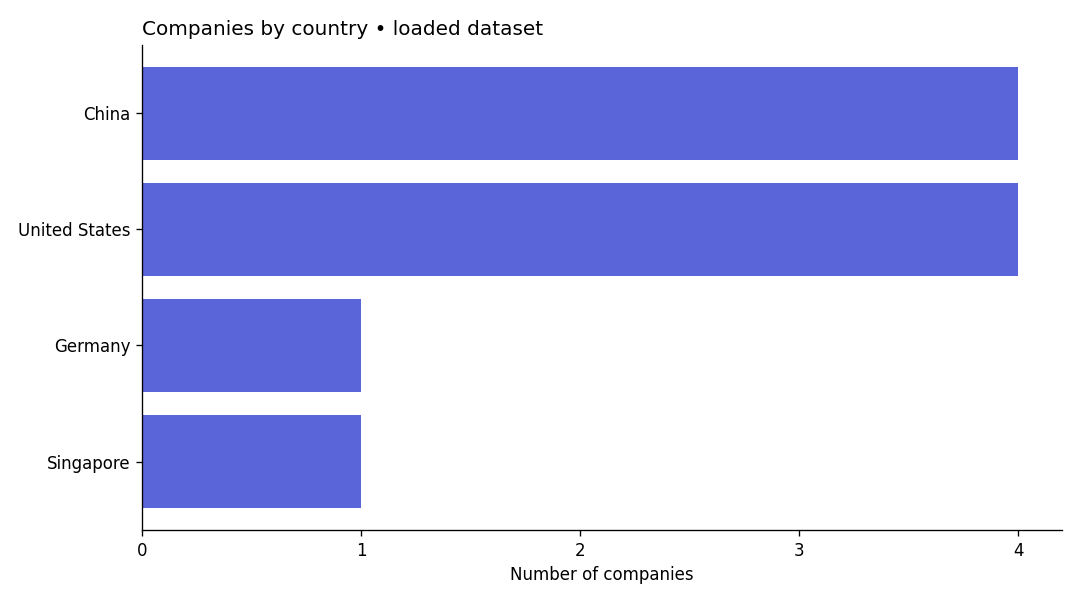

In [6]:
top = by_country.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["country"], top["companies"], color="#5965D8")
ax.set_title("Companies by country • loaded dataset", loc="left")
ax.set_xlabel("Number of companies")
ax.xaxis.get_major_locator().set_params(integer=True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 6. Interpret responsibly
The sample has four companies in China, four in the United States, and one each in Germany and Singapore. These counts reflect the selected screenshot rows. Without the full table and its source date, they do not establish which country leads globally.

**Try next:** Replace the sample with the full dataset, rerun the notebook, and rewrite this interpretation. You can also group by `city` if that field is available.